# Credit Risk Feature Engineering, Preprocessing, Machine Learning and  LightAutoML

| | |
|---|---|
| **Notebook** | B_Feature_Engineering_Preprocessing_and_ML.ipynb |
| **Author** | N L N Sai Krishna Akula |
| **Course** | AAI 500 - Applied Statistics & AI |
| **Dataset** | Credit Risk Modeling Dataset |
| **Date** | June 3, 2026 |
| **GitHub** | https://github.com/diaeshantony-usd/applied-statistics-and-ai-team-project |

This notebook presents a complete modeling workflow from the cleaned credit risk dataset. The workflow includes feature engineering, preprocessing, manual machine learning models, optional LightAutoML benchmarks, regression-based loan sizing, and final model comparison tables.

---
## Modeling Objectives

The project has two modeling goals. The first goal is to predict loan default using `loan_status`, where `0` represents non-default and `1` represents default. This is a classification task.

The second goal is to estimate a reasonable loan amount and loan-to-income percentage. This is a regression task because `loan_amnt` and `loan_percent_income` are numeric targets.

The regression output is a decision-support benchmark based on historical data. It should not be interpreted as a guaranteed loan approval amount.

---
## Setup and Environment

This section imports the required libraries and sets the main configuration values. A fixed random seed is used so train-test splits and model results are reproducible.

LightAutoML is used as an optional AutoML benchmark. The install cell below can be run if the package is not already available in the notebook environment.

In [1]:
# Run this cell only if LightAutoML is not already installed
!pip install lightautoml

  Using cached statsmodels-0.14.0-cp312-cp312-win_amd64.whl.metadata (9.3 kB)
Using cached statsmodels-0.14.0-cp312-cp312-win_amd64.whl (9.1 MB)
  Attempting uninstall: statsmodels
    Found existing installation: statsmodels 0.14.6
    Uninstalling statsmodels-0.14.6:
      Successfully uninstalled statsmodels-0.14.6


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pgmpy 1.1.2 requires statsmodels>=0.14.5, but you have statsmodels 0.14.0 which is incompatible.


In [2]:
# Run this cell only if inferential-statistics and Bayesian Network packages are not already installed
!pip install scipy
!pip install pgmpy networkx

  Using cached statsmodels-0.14.6-cp312-cp312-win_amd64.whl.metadata (9.8 kB)
Using cached statsmodels-0.14.6-cp312-cp312-win_amd64.whl (9.5 MB)
  Attempting uninstall: statsmodels
    Found existing installation: statsmodels 0.14.0
    Uninstalling statsmodels-0.14.0:
      Successfully uninstalled statsmodels-0.14.0


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
lightautoml 0.4.2 requires statsmodels<=0.14.0, but you have statsmodels 0.14.6 which is incompatible.


In [3]:
# Core data libraries
import warnings

import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import networkx as nx
import seaborn as sns

# Inferential statistics
from scipy import stats

# Scikit-learn preprocessing
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

# Scikit-learn model selection and metrics
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
)

# Scikit-learn estimators
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

RANDOM_STATE = 42
TEST_SIZE = 0.20
DATA_PATH = "../data/processed/credit_risk_cleaned.csv"

print("Libraries loaded successfully.")
print("Dataset configured:", DATA_PATH)

Libraries loaded successfully.
Dataset configured: ../data/processed/credit_risk_cleaned.csv


---
## Load and Audit the Cleaned Dataset

The modeling workflow starts from `credit_risk_cleaned.csv`, which is the processed dataset from the data preparation stage. The audit is separated into small outputs so each check is easy to explain in a final project presentation.

The first check confirms that the cleaned file loads correctly and shows the dataset size.

In [4]:
df = pd.read_csv(DATA_PATH)

# Print a short load confirmation without exposing any local full file path.
print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (29724, 12)


The first five rows provide a quick visual check of the columns and sample values.

In [5]:
# Display sample records to verify the dataset structure before modeling.
display(df.head())

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


The missing value audit verifies whether any field still needs imputation before modeling.

In [6]:
missing_audit = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2),
})

# Display missing counts and percentages for each column.
display(missing_audit)

,dtype,missing_count,missing_percent
person_age,int64,0,0.0
person_income,int64,0,0.0
person_home_ownership,str,0,0.0
person_emp_length,float64,0,0.0
loan_intent,str,0,0.0
loan_grade,str,0,0.0
loan_amnt,int64,0,0.0
loan_int_rate,float64,0,0.0
loan_status,int64,0,0.0
loan_percent_income,float64,0,0.0


Duplicate records are checked because repeated rows can overweight the same borrower profile during training.

In [7]:
duplicate_count = int(df.duplicated().sum())

# Print the duplicate count as a simple data-quality check.
print("Duplicate rows:", duplicate_count)

Duplicate rows: 156


The target balance shows the number and percentage of default and non-default loans.

In [8]:
class_balance = (
    df["loan_status"]
    .value_counts(normalize=False)
    .rename_axis("loan_status")
    .reset_index(name="count")
)
class_balance["percent"] = class_balance["count"] / class_balance["count"].sum()

# Display target distribution to show class imbalance before model training.
display(class_balance.style.format({"percent": "{:.2%}"}))

,loan_status,count,percent
0,0,23070,77.61%
1,1,6654,22.39%


Categorical levels are reviewed before encoding so the preprocessing choices are clear.

In [9]:
# Collect categorical columns and list their levels before encoding.
categorical_cols_initial = df.select_dtypes(include=["object", "category"]).columns.tolist()
categorical_summary = {
    col: sorted(df[col].dropna().astype(str).unique().tolist())
    for col in categorical_cols_initial
}
display(pd.DataFrame({
    "column": list(categorical_summary.keys()),
    "levels": [", ".join(vals) for vals in categorical_summary.values()],
}))

,column,levels
0,person_home_ownership,"MORTGAGE, OTHER, OWN, RENT"
1,loan_intent,"DEBTCONSOLIDATION, EDUCATION, HOMEIMPROVEMENT,..."
2,loan_grade,"A, B, C, D, E, F, G"
3,cb_person_default_on_file,"N, Y"


Numeric summary statistics show the scale and range of each numeric field before feature engineering.

In [10]:
# Review numeric ranges and distributions before feature engineering.
display(df.describe().T.round(3))

,count,mean,std,min,25%,50%,75%,max
person_age,29724.0,26.716,4.503,20.00,23.00,25.00,29.00,40.00
person_income,29724.0,58573.009,27478.037,4080.00,37800.00,54000.00,75000.00,140004.00
person_emp_length,29724.0,4.632,3.829,0.00,2.00,4.00,7.00,123.00
loan_amnt,29724.0,9275.315,6025.816,500.00,5000.00,8000.00,12000.00,35000.00
loan_int_rate,29724.0,10.995,3.077,5.42,8.49,10.99,13.11,23.22
loan_status,29724.0,0.224,0.417,0.00,0.00,0.00,0.00,1.00
loan_percent_income,29724.0,0.175,0.107,0.01,0.09,0.15,0.23,0.83
cb_person_cred_hist_length,29724.0,5.263,3.312,2.00,3.00,4.00,7.00,17.00


---
## Final Modeling Sanity Check

The cleaned dataset is the correct starting point, but one final logic check is useful before modeling. Employment length should not be greater than borrower age. Such rows are removed because they are not realistic borrower records.

In [11]:
# Flag records where employment length is greater than borrower age.
invalid_emp_mask = df["person_emp_length"] > df["person_age"]
invalid_emp_count = int(invalid_emp_mask.sum())
print("Rows where person_emp_length > person_age:", invalid_emp_count)

Rows where person_emp_length > person_age: 1


In [12]:
# Remove unrealistic employment records and reset the row index.
df = df.loc[~invalid_emp_mask].copy().reset_index(drop=True)
print("Modeling dataset shape after sanity check:", df.shape)

Modeling dataset shape after sanity check: (29723, 12)


In [13]:
# Print final data-quality counts after the modeling sanity check.
remaining_missing = int(df.isna().sum().sum())
remaining_invalid_emp = int((df["person_emp_length"] > df["person_age"]).sum())
print("Remaining missing values:", remaining_missing)
print("Remaining invalid employment rows:", remaining_invalid_emp)

Remaining missing values: 0
Remaining invalid employment rows: 0


---
## Feature Engineering

This step transforms the cleaned borrower and loan variables into features that better represent affordability, loan burden, and prior credit behavior.

Log transformations reduce the influence of very large financial values. Ratio features compare borrower capacity with requested loan size. Grouped features such as `income_group`, `loan_amount_group`, `loan_percent_income_group`, and `age_group` make default patterns easier to explain.

In [14]:
def add_credit_features(data):
    # Copy the input so the original cleaned dataset is not modified directly.
    out = data.copy()

    # Log transforms reduce the influence of very large income and loan values.
    out["log_person_income"] = np.log1p(out["person_income"])
    out["log_loan_amnt"] = np.log1p(out["loan_amnt"])

    # Ratio features describe affordability and borrower history in relative terms.
    out["income_to_loan_ratio"] = out["person_income"] / out["loan_amnt"].clip(lower=1)
    out["employment_to_age_ratio"] = out["person_emp_length"] / out["person_age"].clip(lower=1)
    out["credit_history_to_age_ratio"] = out["cb_person_cred_hist_length"] / out["person_age"].clip(lower=1)
    out["default_on_file_binary"] = (out["cb_person_default_on_file"] == "Y").astype(int)

    # Numeric grade is useful for analysis while model preprocessing still handles grade encoding.
    grade_map = {"A": 0, "B": 1, "C": 2, "D": 3, "E": 4, "F": 5, "G": 6}
    out["loan_grade_numeric"] = out["loan_grade"].map(grade_map)

    # Grouped features make borrower and loan risk patterns easier to explain.
    out["income_group"] = pd.cut(
        out["person_income"],
        bins=[0, 25000, 50000, 75000, 100000, np.inf],
        labels=["Low", "Lower-Middle", "Middle", "Upper-Middle", "High"],
        include_lowest=True,
    )
    out["loan_amount_group"] = pd.cut(
        out["loan_amnt"],
        bins=[0, 5000, 10000, 20000, np.inf],
        labels=["Small", "Medium", "Large", "Very Large"],
        include_lowest=True,
    )
    out["loan_percent_income_group"] = pd.cut(
        out["loan_percent_income"],
        bins=[0, 0.10, 0.20, 0.35, np.inf],
        labels=["Low Burden", "Moderate Burden", "High Burden", "Very High Burden"],
        include_lowest=True,
    )
    out["age_group"] = pd.cut(
        out["person_age"],
        bins=[0, 25, 35, np.inf],
        labels=["Young", "Adult", "Experienced Adult"],
        include_lowest=True,
    )
    # Return the feature-engineered dataframe for all later modeling steps.
    return out

In [15]:
df_model = add_credit_features(df)

# Print the new shape after engineered columns are added.
print("Feature-engineered dataset shape:", df_model.shape)

Feature-engineered dataset shape: (29723, 23)


In [16]:
# Preview engineered columns to confirm the feature creation step.
display(df_model.head())

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,log_person_income,log_loan_amnt,income_to_loan_ratio,employment_to_age_ratio,credit_history_to_age_ratio,default_on_file_binary,loan_grade_numeric,income_group,loan_amount_group,loan_percent_income_group,age_group
0,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2,9.169623,6.908755,9.600000,0.238095,0.095238,0,1,Low,Small,Low Burden,Young
1,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3,9.169623,8.612685,1.745455,0.040000,0.120000,0,2,Low,Medium,Very High Burden,Young
2,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2,11.089821,10.463132,1.871429,0.173913,0.086957,0,2,Middle,Very Large,Very High Burden,Young
3,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4,10.904138,10.463132,1.554286,0.333333,0.166667,1,2,Middle,Very Large,Very High Burden,Young
4,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2,9.200391,7.824446,3.960000,0.095238,0.095238,0,0,Low,Small,High Burden,Young


---
## Grouped Feature Default Rate EDA

Grouped features help explain whether risk changes across borrower and loan categories. The outputs below show default rate separately for income group, loan amount group, and loan burden group.

In [17]:
def summarize_default_rate_by_group(data, group_col):
    # Group by the selected category and calculate default rate plus loan-size context.
    summary = (
        data.groupby(group_col, observed=False)
        .agg(
            loan_count=("loan_status", "size"),
            default_rate=("loan_status", "mean"),
            avg_loan_amount=("loan_amnt", "mean"),
            avg_loan_percent_income=("loan_percent_income", "mean"),
        )
        .reset_index()
    )
    # Return a compact table that can be displayed or plotted.
    return summary

The income group table shows whether lower or higher income bands have different default rates.

In [18]:
income_group_summary = summarize_default_rate_by_group(df_model, "income_group")

# Display default rate by income band.
display(income_group_summary.style.format({
    "default_rate": "{:.2%}",
    "avg_loan_amount": "{:.2f}",
    "avg_loan_percent_income": "{:.2%}",
}))

,income_group,loan_count,default_rate,avg_loan_amount,avg_loan_percent_income
0,Low,2374,52.23%,4667.93,23.93%
1,Lower-Middle,11149,27.70%,7664.01,20.13%
2,Middle,9179,17.50%,9998.73,16.05%
3,Upper-Middle,4439,10.88%,11893.47,13.66%
4,High,2582,9.14%,13386.25,11.42%


The loan amount group table checks whether larger requested loans behave differently from smaller loans.

In [19]:
loan_amount_group_summary = summarize_default_rate_by_group(df_model, "loan_amount_group")

# Display default rate by loan amount band.
display(loan_amount_group_summary.style.format({
    "default_rate": "{:.2%}",
    "avg_loan_amount": "{:.2f}",
    "avg_loan_percent_income": "{:.2%}",
}))

,loan_amount_group,loan_count,default_rate,avg_loan_amount,avg_loan_percent_income
0,Small,8946,20.77%,3471.15,9.29%
1,Medium,11151,18.39%,7849.34,16.80%
2,Large,8014,26.38%,14538.80,24.58%
3,Very Large,1612,39.08%,25167.29,31.78%


The loan percent income group table focuses on loan burden, which is usually more informative than loan amount alone.

In [20]:
loan_percent_income_group_summary = summarize_default_rate_by_group(df_model, "loan_percent_income_group")

# Display default rate by loan burden band.
display(loan_percent_income_group_summary.style.format({
    "default_rate": "{:.2%}",
    "avg_loan_amount": "{:.2f}",
    "avg_loan_percent_income": "{:.2%}",
}))

,loan_percent_income_group,loan_count,default_rate,avg_loan_amount,avg_loan_percent_income
0,Low Burden,9028,12.15%,4535.84,6.76%
1,Moderate Burden,11115,15.05%,9096.54,15.23%
2,High Burden,7497,31.91%,13204.20,26.58%
3,Very High Burden,2083,71.58%,16617.85,42.78%


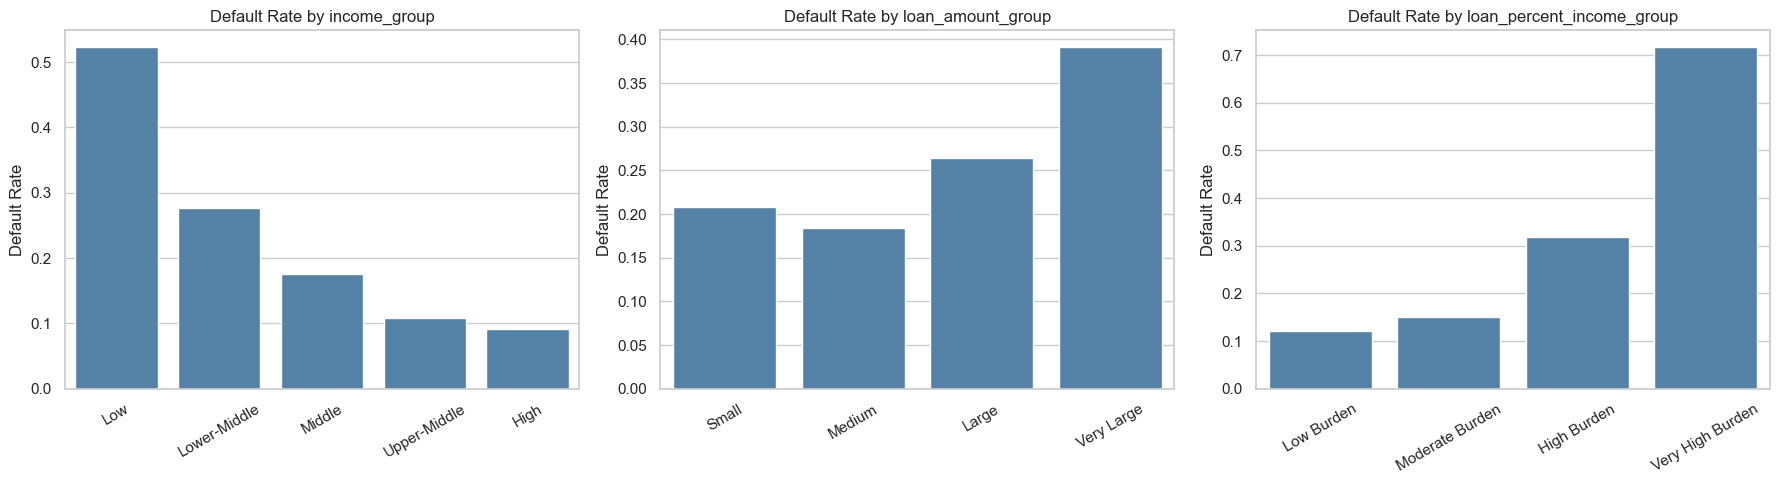

In [21]:
# Store grouped summaries so the plots can be generated consistently.
group_feature_summaries = {
    "income_group": income_group_summary,
    "loan_amount_group": loan_amount_group_summary,
    "loan_percent_income_group": loan_percent_income_group_summary,
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, group_name in zip(axes, group_feature_summaries.keys()):
    summary = group_feature_summaries[group_name]
    sns.barplot(data=summary, x=group_name, y="default_rate", color="steelblue", ax=ax)
    ax.set_title(f"Default Rate by {group_name}")
    ax.set_xlabel("")
    ax.set_ylabel("Default Rate")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

---
## Income Transformation Check

The histogram comparison checks whether the log income feature reduces skewness. A lower skewness value after transformation means the feature is more balanced for modeling.

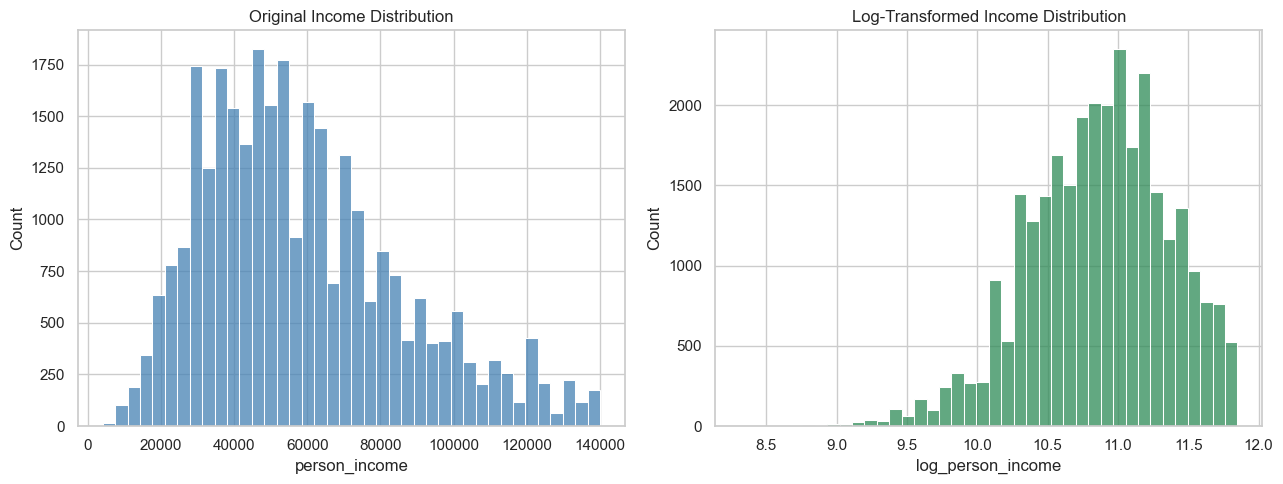

In [22]:
# Compare original income and log-transformed income distributions.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(df_model["person_income"], bins=40, color="steelblue", ax=axes[0])
axes[0].set_title("Original Income Distribution")
axes[0].set_xlabel("person_income")
sns.histplot(df_model["log_person_income"], bins=40, color="seagreen", ax=axes[1])
axes[1].set_title("Log-Transformed Income Distribution")
axes[1].set_xlabel("log_person_income")
plt.tight_layout()
plt.show()

In [23]:
# Quantify how much the log transform changes income skewness.
income_skewness = pd.DataFrame([
    {"feature": "person_income", "skewness": df_model["person_income"].skew()},
    {"feature": "log_person_income", "skewness": df_model["log_person_income"].skew()},
])
display(income_skewness.style.format({"skewness": "{:.4f}"}))

,feature,skewness
0,person_income,0.7419
1,log_person_income,-0.4397


---
## Credit Grade and Interest Rate Analysis

The main classification model uses an issued-loan framing, so `loan_grade` and `loan_int_rate` are included because those values are known after underwriting. This section checks how default rate and interest rate change across grades.

In [24]:
# Summarize default behavior and interest rate patterns by loan grade.
grade_summary = (
    df_model.groupby("loan_grade")
    .agg(
        loan_count=("loan_status", "size"),
        default_rate=("loan_status", "mean"),
        avg_interest_rate=("loan_int_rate", "mean"),
        avg_loan_percent_income=("loan_percent_income", "mean"),
    )
    .reset_index()
)
display(grade_summary.style.format({
    "default_rate": "{:.2%}",
    "avg_interest_rate": "{:.2f}",
    "avg_loan_percent_income": "{:.2%}",
}))

,loan_grade,loan_count,default_rate,avg_interest_rate,avg_loan_percent_income
0,A,9889,10.46%,7.66,15.74%
1,B,9501,16.87%,11.00,17.98%
2,C,5916,21.60%,13.23,17.45%
3,D,3291,59.89%,14.98,19.60%
4,E,858,65.15%,16.44,21.22%
5,F,209,71.77%,17.76,22.62%
6,G,59,98.31%,19.38,24.95%


In [25]:
# Compare average interest rates for defaulted and non-defaulted loans.
rate_by_status = (
    df_model.groupby("loan_status")["loan_int_rate"]
    .mean()
    .rename("avg_interest_rate")
    .reset_index()
)
display(rate_by_status.style.format({"avg_interest_rate": "{:.2f}"}))

,loan_status,avg_interest_rate
0,0,10.47
1,1,12.81


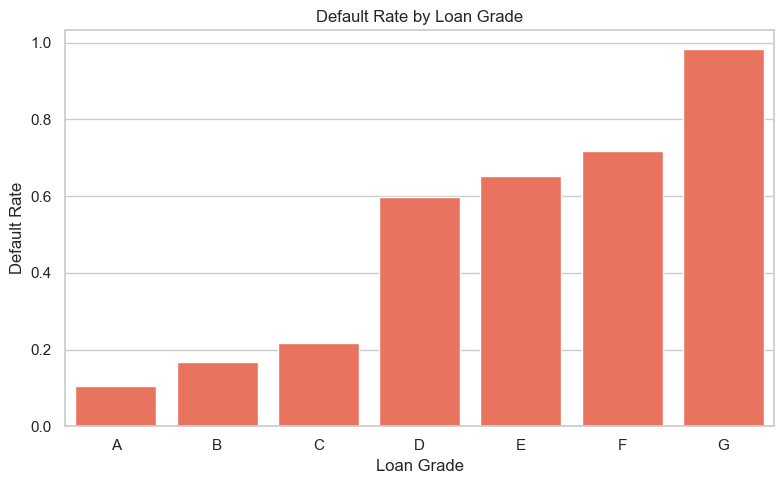

In [26]:
# Plot a focused relationship so grade-level risk is easier to read.
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=grade_summary, x="loan_grade", y="default_rate", color="tomato", ax=ax)
ax.set_title("Default Rate by Loan Grade")
ax.set_xlabel("Loan Grade")
ax.set_ylabel("Default Rate")
plt.tight_layout()
plt.show()

---
## Inferential Statistics

Inferential statistics help evaluate whether observed differences in the sample are likely to be meaningful. This dataset supports mean-comparison tests for borrower, loan, and credit-history variables.

Welch's t-test is used for two-group comparisons between default and non-default loans because it does not assume equal variance between the groups. One-way ANOVA is used to compare numeric means across more than two credit grades.

**H0** means the null hypothesis. It represents the assumption that there is no real difference between the groups being compared. If the p-value is below 0.05, the result rejects H0, meaning the observed difference is unlikely to be explained by random variation alone.

In [27]:
ALPHA = 0.05

ttest_numeric_features = [
    "person_income", "loan_amnt", "loan_percent_income",
    "loan_int_rate", "person_emp_length", "cb_person_cred_hist_length",
]


def run_welch_tests(data, features, target_col="loan_status", alpha=ALPHA):
    # Welch's t-test compares numeric means between default and non-default loans.
    rows = []
    for feature in features:
        non_default_values = data.loc[data[target_col] == 0, feature].dropna()
        default_values = data.loc[data[target_col] == 1, feature].dropna()

        # equal_var=False applies Welch's version of the independent t-test.
        statistic, p_value = stats.ttest_ind(
            non_default_values,
            default_values,
            equal_var=False,
            nan_policy="omit",
        )
        decision = "Reject H0" if p_value < alpha else "Fail to reject H0"
        interpretation = (
            "Reject H0: evidence suggests the mean differs by default status."
            if p_value < alpha
            else "Fail to reject H0: no statistically significant mean difference found."
        )
        rows.append({
            "test": "Welch t-test",
            "feature": feature,
            "h0": f"The mean {feature} is the same for default and non-default loans.",
            "statistic": statistic,
            "p_value": p_value,
            "decision": decision,
            "interpretation": interpretation,
        })
    return pd.DataFrame(rows)


welch_results = run_welch_tests(df_model, ttest_numeric_features)

# Display Welch test results for default vs non-default groups.
display(welch_results.style.format({"statistic": "{:.4f}", "p_value": "{:.6f}"}))

,test,feature,h0,statistic,p_value,decision,interpretation
0,Welch t-test,person_income,The mean person_income is the same for default and non-default loans.,49.1706,0.000000,Reject H0,Reject H0: evidence suggests the mean differs by default status.
1,Welch t-test,loan_amnt,The mean loan_amnt is the same for default and non-default loans.,-18.6353,0.000000,Reject H0,Reject H0: evidence suggests the mean differs by default status.
2,Welch t-test,loan_percent_income,The mean loan_percent_income is the same for default and non-default loans.,-56.9577,0.000000,Reject H0,Reject H0: evidence suggests the mean differs by default status.
3,Welch t-test,loan_int_rate,The mean loan_int_rate is the same for default and non-default loans.,-54.1025,0.000000,Reject H0,Reject H0: evidence suggests the mean differs by default status.
4,Welch t-test,person_emp_length,The mean person_emp_length is the same for default and non-default loans.,15.2810,0.000000,Reject H0,Reject H0: evidence suggests the mean differs by default status.
5,Welch t-test,cb_person_cred_hist_length,The mean cb_person_cred_hist_length is the same for default and non-default loans.,3.0714,0.002136,Reject H0,Reject H0: evidence suggests the mean differs by default status.


In [28]:
anova_numeric_features = ["loan_int_rate", "loan_percent_income", "loan_amnt", "person_income"]


def run_grade_anova(data, features, group_col="loan_grade", alpha=ALPHA):
    # One-way ANOVA compares numeric means across all loan-grade groups.
    rows = []
    for feature in features:
        grouped_values = [
            group[feature].dropna()
            for _, group in data.groupby(group_col)
            if group[feature].dropna().shape[0] > 1
        ]

        # ANOVA requires at least two groups with enough observations.
        if len(grouped_values) >= 2:
            statistic, p_value = stats.f_oneway(*grouped_values)
        else:
            statistic, p_value = np.nan, np.nan

        decision = "Reject H0" if pd.notna(p_value) and p_value < alpha else "Fail to reject H0"
        interpretation = (
            "Reject H0: at least one grade group has a different mean."
            if pd.notna(p_value) and p_value < alpha
            else "Fail to reject H0: no statistically significant grade-level mean difference found."
        )
        rows.append({
            "test": "One-way ANOVA",
            "feature": feature,
            "h0": f"The mean {feature} is the same across all loan grades.",
            "statistic": statistic,
            "p_value": p_value,
            "decision": decision,
            "interpretation": interpretation,
        })
    return pd.DataFrame(rows)


anova_results = run_grade_anova(df_model, anova_numeric_features)

# Display ANOVA results for numeric variables across loan grades.
display(anova_results.style.format({"statistic": "{:.4f}", "p_value": "{:.6f}"}))

,test,feature,h0,statistic,p_value,decision,interpretation
0,One-way ANOVA,loan_int_rate,The mean loan_int_rate is the same across all loan grades.,22518.7442,0.000000,Reject H0,Reject H0: at least one grade group has a different mean.
1,One-way ANOVA,loan_percent_income,The mean loan_percent_income is the same across all loan grades.,100.5757,0.000000,Reject H0,Reject H0: at least one grade group has a different mean.
2,One-way ANOVA,loan_amnt,The mean loan_amnt is the same across all loan grades.,145.7124,0.000000,Reject H0,Reject H0: at least one grade group has a different mean.
3,One-way ANOVA,person_income,The mean person_income is the same across all loan grades.,18.7755,0.000000,Reject H0,Reject H0: at least one grade group has a different mean.


---
## Bayesian Network Model

A Bayesian Network represents probabilistic dependencies among discrete variables as a Directed Acyclic Graph (DAG). For this dataset, the network can be learned from grouped borrower and loan variables such as income group, loan burden group, prior default flag, loan intent, and loan grade.

This section is used for probabilistic structure interpretation. Because the data is observational, the learned DAG should not be treated as proof of real-world causality.

The fitted Bayesian Network can also estimate default probability for test records. It is included as a supporting classification model, but the main predictive models remain the manual machine learning models and LightAutoML because they use richer numeric information.

In [29]:
# Run this focused analysis step and display the result for project review.
try:
    from pgmpy.inference import VariableElimination
    from pgmpy.estimators import HillClimbSearch
    try:
        from pgmpy.estimators import DiscreteMLE
    except ImportError:
        DiscreteMLE = None
    try:
        from pgmpy.estimators import BicScore
    except ImportError:
        BicScore = None
    try:
        from pgmpy.models import DiscreteBayesianNetwork as PgmpyBayesianNetwork
    except ImportError:
        from pgmpy.models import BayesianNetwork as PgmpyBayesianNetwork
    PGMPY_AVAILABLE = True
    print("pgmpy imported successfully. Bayesian Network structure learning is available.")
except ImportError as pgmpy_error:
    PGMPY_AVAILABLE = False
    print("pgmpy import failed. Bayesian Network structure learning is skipped.")
    print("Import error:", pgmpy_error)
    print("Run the setup install cell above, then restart the notebook kernel if this message still appears.")

pgmpy imported successfully. Bayesian Network structure learning is available.


In [30]:
bn_cols = [
    "income_group", "loan_amount_group", "loan_percent_income_group",
    "age_group", "person_home_ownership", "loan_intent",
    "cb_person_default_on_file", "loan_grade", "loan_status",
]

# Use only discrete/grouped variables because Bayesian Networks in this section are categorical.
bn_data = df_model[bn_cols].copy()
bn_data["loan_status"] = bn_data["loan_status"].map({0: "Non-Default", 1: "Default"})
bn_data = bn_data.astype(str)

# Split the discrete Bayesian Network data for training and prediction evaluation.
bn_train_data, bn_test_data = train_test_split(
    bn_data,
    test_size=TEST_SIZE,
    stratify=bn_data["loan_status"],
    random_state=RANDOM_STATE,
)

# Use a training sample for structure learning so the section remains practical to run.
bn_learning_data = bn_train_data.sample(n=min(5000, len(bn_train_data)), random_state=RANDOM_STATE)
print("Bayesian Network training rows:", bn_train_data.shape[0])
print("Bayesian Network test rows:", bn_test_data.shape[0])
print("Bayesian Network structure-learning rows:", bn_learning_data.shape[0])
display(bn_learning_data.head())

Bayesian Network training rows: 23778
Bayesian Network test rows: 5945
Bayesian Network structure-learning rows: 5000


,income_group,loan_amount_group,loan_percent_income_group,age_group,person_home_ownership,loan_intent,cb_person_default_on_file,loan_grade,loan_status
11309,Middle,Medium,Low Burden,Young,MORTGAGE,EDUCATION,N,B,Non-Default
18559,Upper-Middle,Small,Low Burden,Adult,RENT,EDUCATION,N,A,Non-Default
20691,Lower-Middle,Small,Low Burden,Adult,MORTGAGE,HOMEIMPROVEMENT,N,C,Default
4766,Lower-Middle,Small,Moderate Burden,Young,RENT,EDUCATION,N,C,Default
13427,Upper-Middle,Medium,Low Burden,Young,MORTGAGE,DEBTCONSOLIDATION,N,B,Non-Default


In [31]:
bn_model = None
bn_edges = []
bn_metrics = None
if PGMPY_AVAILABLE:
    # HillClimbSearch learns a DAG structure using a discrete scoring method.
    hill_search = HillClimbSearch(bn_learning_data)
    try:
        if BicScore is not None:
            learned_structure = hill_search.estimate(
                scoring_method=BicScore(bn_learning_data),
                max_indegree=3,
            )
        else:
            learned_structure = hill_search.estimate(scoring_method="bic-d", max_indegree=3)
    except TypeError:
        learned_structure = hill_search.estimate(scoring_method="bic-d")

    # Fit conditional probability tables on the learned graph.
    bn_edges = list(learned_structure.edges())
    bn_model = PgmpyBayesianNetwork(bn_edges)
    bn_model.add_nodes_from(bn_cols)
    try:
        # Newer pgmpy versions automatically choose a valid discrete estimator.
        bn_model.fit(bn_learning_data)
        print("Bayesian Network parameters fitted with the default pgmpy discrete estimator.")
    except TypeError:
        if DiscreteMLE is None:
            raise
        # Some pgmpy versions require an initialized estimator object.
        bn_model.fit(bn_learning_data, estimator=DiscreteMLE())
        print("Bayesian Network parameters fitted with DiscreteMLE.")

    bn_edge_table = pd.DataFrame(bn_edges, columns=["from", "to"])
    if bn_edge_table.empty:
        print("No edges were learned from the selected variables.")
    else:
        display(bn_edge_table)
else:
    print("Bayesian Network structure learning was skipped because pgmpy is unavailable.")

  0%|          | 11/1000000 [00:00<12:38:42, 21.97it/s]

Bayesian Network parameters fitted with the default pgmpy discrete estimator.


,from,to
0,income_group,loan_percent_income_group
1,income_group,person_home_ownership
2,loan_amount_group,loan_percent_income_group
3,loan_amount_group,income_group
4,loan_intent,age_group
5,cb_person_default_on_file,loan_grade
6,loan_grade,loan_status
7,loan_status,income_group
8,loan_status,person_home_ownership
9,loan_status,loan_intent


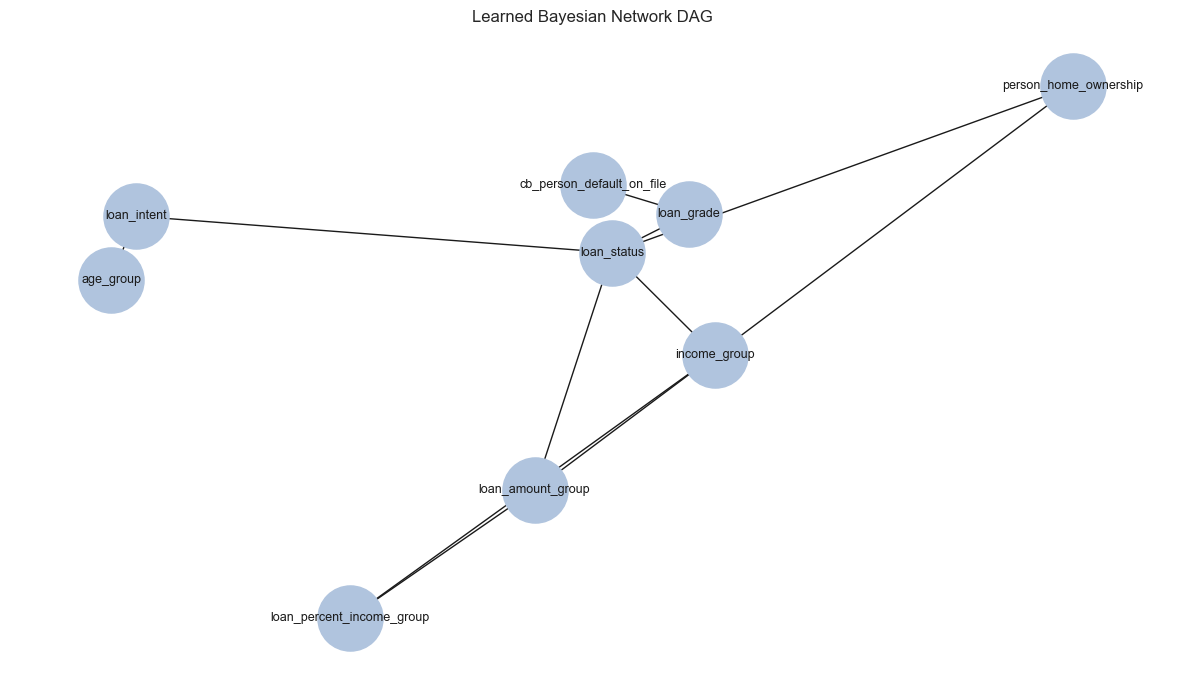

In [32]:
if PGMPY_AVAILABLE and bn_model is not None:
    # Plot the learned DAG so dependencies among grouped variables are visible.
    dag = nx.DiGraph()
    dag.add_nodes_from(bn_cols)
    dag.add_edges_from(bn_edges)

    plt.figure(figsize=(12, 7))
    pos = nx.spring_layout(dag, seed=RANDOM_STATE)
    nx.draw_networkx_nodes(dag, pos, node_color="lightsteelblue", node_size=2200)
    nx.draw_networkx_edges(dag, pos, arrows=True, arrowstyle="-|>", arrowsize=18)
    nx.draw_networkx_labels(dag, pos, font_size=9)
    plt.title("Learned Bayesian Network DAG")
    plt.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("DAG plot skipped because no Bayesian Network model is available.")

In [33]:
def predict_default_probability_with_bn(model, row, target_col="loan_status"):
    # VariableElimination returns a probability table for loan_status using applicant evidence.
    inference = VariableElimination(model)
    fallback_probability = float((bn_train_data[target_col] == "Default").mean())
    evidence = {
        col: str(row[col])
        for col in bn_cols
        if col != target_col and col in model.nodes()
    }

    try:
        query_result = inference.query(
            variables=[target_col],
            evidence=evidence,
            show_progress=False,
        )
        target_states = list(query_result.state_names[target_col])
        default_index = target_states.index("Default")
        predicted_probability = float(query_result.values[default_index])
        if not np.isfinite(predicted_probability):
            return fallback_probability
        return predicted_probability
    except Exception:
        # If a rare evidence combination is unavailable, fall back to the training default rate.
        return fallback_probability


if PGMPY_AVAILABLE and bn_model is not None:
    fallback_probability = float((bn_train_data["loan_status"] == "Default").mean())

    # Predict default probability for each Bayesian Network test record.
    bn_default_prob = bn_test_data.apply(
        lambda row: predict_default_probability_with_bn(bn_model, row),
        axis=1,
    )
    bn_default_prob = pd.to_numeric(bn_default_prob, errors="coerce")
    bn_default_prob = bn_default_prob.replace([np.inf, -np.inf], np.nan)
    fallback_count = int(bn_default_prob.isna().sum())
    bn_default_prob = bn_default_prob.fillna(fallback_probability)

    bn_true = (bn_test_data["loan_status"] == "Default").astype(int)
    bn_pred = (bn_default_prob >= 0.50).astype(int)

    print("Bayesian Network fallback probability:", round(fallback_probability, 4))
    print("Bayesian Network fallback predictions used:", fallback_count)

    # Report the Bayesian Network as a supporting classification model.
    bn_metrics = pd.DataFrame([{
        "model_source": "Bayesian Network",
        "model": "pgmpy HillClimbSearch + VariableElimination",
        "roc_auc": roc_auc_score(bn_true, bn_default_prob),
        "accuracy": accuracy_score(bn_true, bn_pred),
        "precision": precision_score(bn_true, bn_pred, zero_division=0),
        "recall": recall_score(bn_true, bn_pred, zero_division=0),
        "f1": f1_score(bn_true, bn_pred, zero_division=0),
    }])
    display(bn_metrics.style.format({
        "roc_auc": "{:.4f}", "accuracy": "{:.4f}", "precision": "{:.4f}",
        "recall": "{:.4f}", "f1": "{:.4f}",
    }))
else:
    print("Bayesian Network prediction metrics skipped because no fitted model is available.")

Bayesian Network fallback probability: 0.2238
Bayesian Network fallback predictions used: 0


,model_source,model,roc_auc,accuracy,precision,recall,f1
0,Bayesian Network,pgmpy HillClimbSearch + VariableElimination,0.8474,0.8353,0.7152,0.4395,0.5444


In [34]:
def summarize_default_probability(data, group_cols):
    # Empirical conditional probabilities support interpretation even when pgmpy is unavailable.
    summary = (
        data.groupby(group_cols, observed=False)
        .agg(
            loan_count=("loan_status", "size"),
            default_probability=("loan_status", "mean"),
        )
        .reset_index()
        .sort_values("default_probability", ascending=False)
    )
    return summary


bn_probability_by_burden = summarize_default_probability(
    df_model, ["loan_percent_income_group", "cb_person_default_on_file"]
)

# Display conditional default probabilities by loan burden and prior default flag.
display(bn_probability_by_burden.style.format({"default_probability": "{:.2%}"}))

,loan_percent_income_group,cb_person_default_on_file,loan_count,default_probability
7,Very High Burden,Y,404,78.96%
6,Very High Burden,N,1679,69.80%
5,High Burden,Y,1496,47.99%
3,Moderate Burden,Y,1850,31.24%
4,High Burden,N,6001,27.90%
1,Low Burden,Y,1467,26.58%
2,Moderate Burden,N,9265,11.82%
0,Low Burden,N,7561,9.35%


---
## Preprocessing Pipeline

The preprocessing pipeline converts raw modeling columns into a numeric matrix. Numeric fields are imputed and scaled, nominal fields are one-hot encoded, binary fields are encoded as 0/1, and loan grade is ordinal encoded from A through G.

In [35]:
# Define target names and feature groups used by the models.
classification_target = "loan_status"
loan_amount_target = "loan_amnt"
loan_percent_target = "loan_percent_income"

numeric_cols = [
    "person_age", "person_income", "person_emp_length", "loan_amnt",
    "loan_percent_income", "loan_int_rate", "cb_person_cred_hist_length",
    "log_person_income", "log_loan_amnt", "income_to_loan_ratio",
    "employment_to_age_ratio", "credit_history_to_age_ratio",
    "default_on_file_binary", "loan_grade_numeric",
]
nominal_cols = [
    "person_home_ownership", "loan_intent", "income_group",
    "loan_amount_group", "loan_percent_income_group", "age_group",
]
binary_cols = ["cb_person_default_on_file"]
ordinal_cols = ["loan_grade"]

classification_feature_cols = numeric_cols + nominal_cols + binary_cols + ordinal_cols
regression_feature_cols = [
    "person_age", "person_income", "person_emp_length",
    "cb_person_cred_hist_length", "log_person_income",
    "employment_to_age_ratio", "credit_history_to_age_ratio",
    "default_on_file_binary", "person_home_ownership", "loan_intent",
    "income_group", "age_group", "cb_person_default_on_file",
]

feature_counts = pd.DataFrame([
    {"feature_set": "classification", "feature_count": len(classification_feature_cols)},
    {"feature_set": "regression", "feature_count": len(regression_feature_cols)},
])
display(feature_counts)

,feature_set,feature_count
0,classification,22
1,regression,13


In [36]:
def make_one_hot_encoder():
    # Use the correct OneHotEncoder argument name for the installed scikit-learn version.
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def make_credit_preprocessor(feature_cols):
    # Keep only the columns that are included in the current model feature set.
    model_numeric_cols = [col for col in numeric_cols if col in feature_cols]
    model_nominal_cols = [col for col in nominal_cols if col in feature_cols]
    model_binary_cols = [col for col in binary_cols if col in feature_cols]
    model_ordinal_cols = [col for col in ordinal_cols if col in feature_cols]
    transformers = []

    # Numeric features are median-imputed and standardized for scale-sensitive models.
    if model_numeric_cols:
        transformers.append(("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), model_numeric_cols))
    # Nominal categorical features are imputed and one-hot encoded.
    if model_nominal_cols:
        transformers.append(("nom", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", make_one_hot_encoder()),
        ]), model_nominal_cols))
    # The default-on-file flag is encoded with a fixed N/Y order.
    if model_binary_cols:
        transformers.append(("bin", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ordinal", OrdinalEncoder(categories=[["N", "Y"]])),
        ]), model_binary_cols))
    # Loan grade is ordinal because grades A through G represent increasing credit risk.
    if model_ordinal_cols:
        transformers.append(("grade", OrdinalEncoder(
            categories=[["A", "B", "C", "D", "E", "F", "G"]],
            handle_unknown="use_encoded_value",
            unknown_value=-1,
        ), model_ordinal_cols))

    # ColumnTransformer combines all preprocessing steps into one reusable object.
    return ColumnTransformer(transformers=transformers, remainder="drop")

---
## Manual ML Classification Model

Manual models provide a transparent baseline. The result table compares Logistic Regression, Random Forest, Gradient Boosting, and CatBoost if installed.

In [37]:
# Split classification features and target into train and test datasets.
X_cls = df_model[classification_feature_cols].copy()
y_cls = df_model[classification_target].copy()
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls, test_size=TEST_SIZE, stratify=y_cls, random_state=RANDOM_STATE
)
split_summary = pd.DataFrame([
    {"dataset": "train", "rows": X_train_cls.shape[0], "features": X_train_cls.shape[1]},
    {"dataset": "test", "rows": X_test_cls.shape[0], "features": X_test_cls.shape[1]},
])
display(split_summary)

,dataset,rows,features
0,train,23778,22
1,test,5945,22


In [38]:
# Define the manual classification models for comparison.
classification_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}
try:
    from catboost import CatBoostClassifier
    classification_models["CatBoost"] = CatBoostClassifier(
        iterations=300, learning_rate=0.05, depth=6,
        eval_metric="AUC", random_seed=RANDOM_STATE, verbose=0,
    )
except ImportError:
    print("CatBoost is not installed. Continuing with scikit-learn classifiers.")

In [39]:
def evaluate_classification_models(models, X_train, X_test, y_train, y_test, feature_cols):
    # Store one metric row per model and keep fitted pipelines for later plots.
    rows = []
    fitted_models = {}
    for name, model in models.items():
        # Each model receives the same preprocessing pipeline for a fair comparison.
        pipe = Pipeline([
            ("preprocess", make_credit_preprocessor(feature_cols)),
            ("model", clone(model)),
        ])
        # Fit on training data, then evaluate on the holdout test set.
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)
        y_prob = pipe.predict_proba(X_test)[:, 1]
        # Classification metrics summarize ranking quality and default-class detection.
        rows.append({
            "model": name,
            "roc_auc": roc_auc_score(y_test, y_prob),
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "recall": recall_score(y_test, y_pred, zero_division=0),
            "f1": f1_score(y_test, y_pred, zero_division=0),
        })
        fitted_models[name] = pipe
    # Sort by ROC-AUC because this is the main classification selection metric.
    metrics = pd.DataFrame(rows).sort_values("roc_auc", ascending=False).reset_index(drop=True)
    return metrics, fitted_models


cls_metrics, cls_models = evaluate_classification_models(
    classification_models, X_train_cls, X_test_cls, y_train_cls, y_test_cls, classification_feature_cols
)
manual_cls_best = cls_metrics.iloc[[0]].copy()
manual_cls_best["model_source"] = "Manual"

# Display manual model results so the strongest baseline is visible.
display(cls_metrics.style.format({
    "roc_auc": "{:.4f}", "accuracy": "{:.4f}", "precision": "{:.4f}",
    "recall": "{:.4f}", "f1": "{:.4f}",
}))

,model,roc_auc,accuracy,precision,recall,f1
0,CatBoost,0.9411,0.9374,0.9888,0.7288,0.8391
1,Random Forest,0.9345,0.9265,0.9071,0.7483,0.8201
2,Gradient Boosting,0.9277,0.9307,0.9600,0.7205,0.8232
3,Logistic Regression,0.8763,0.8056,0.5457,0.7844,0.6436


---
## Classification Evaluation

The best manual model is evaluated with a classification report, confusion matrix, ROC curves, and predicted probability distribution.

In [40]:
# Select the best manual classifier and print its detailed report.
best_cls_name = cls_metrics.iloc[0]["model"]
best_cls_model = cls_models[best_cls_name]
y_cls_pred = best_cls_model.predict(X_test_cls)
y_cls_prob = best_cls_model.predict_proba(X_test_cls)[:, 1]
print("Best classification model:", best_cls_name)
print(classification_report(y_test_cls, y_cls_pred, digits=3))

Best classification model: CatBoost
              precision    recall  f1-score   support

           0      0.927     0.998     0.961      4614
           1      0.989     0.729     0.839      1331

    accuracy                          0.937      5945
   macro avg      0.958     0.863     0.900      5945
weighted avg      0.941     0.937     0.934      5945



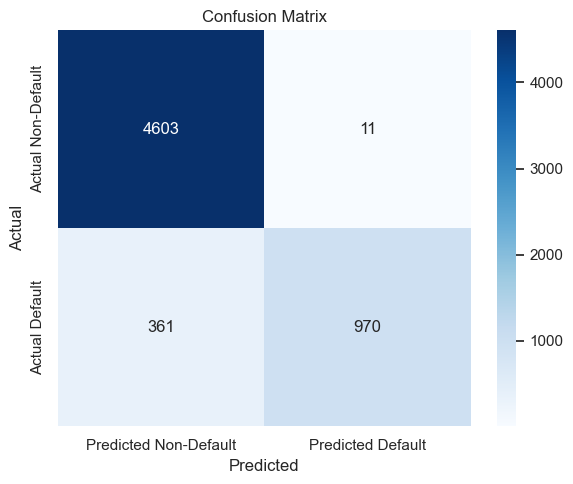

In [41]:
# Build and plot the confusion matrix for the best classifier.
cm = confusion_matrix(y_test_cls, y_cls_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted Non-Default", "Predicted Default"],
            yticklabels=["Actual Non-Default", "Actual Default"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

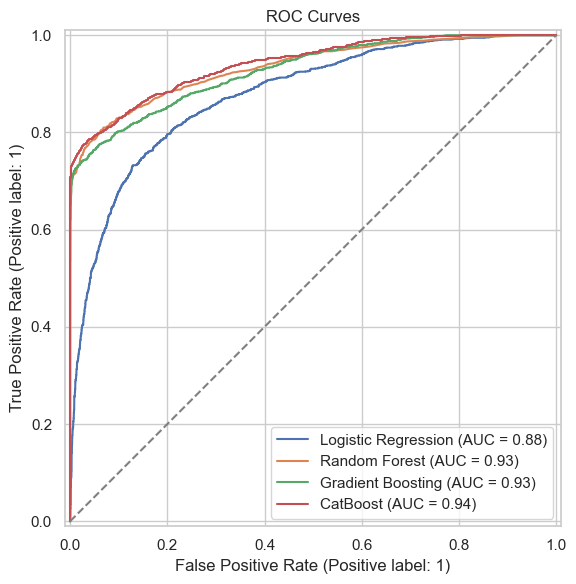

In [42]:
# Plot ROC curves to compare classifier ranking performance.
plt.figure(figsize=(8, 6))
ax = plt.gca()
for name, model in cls_models.items():
    RocCurveDisplay.from_estimator(model, X_test_cls, y_test_cls, ax=ax, name=name)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
ax.set_title("ROC Curves")
plt.tight_layout()
plt.show()

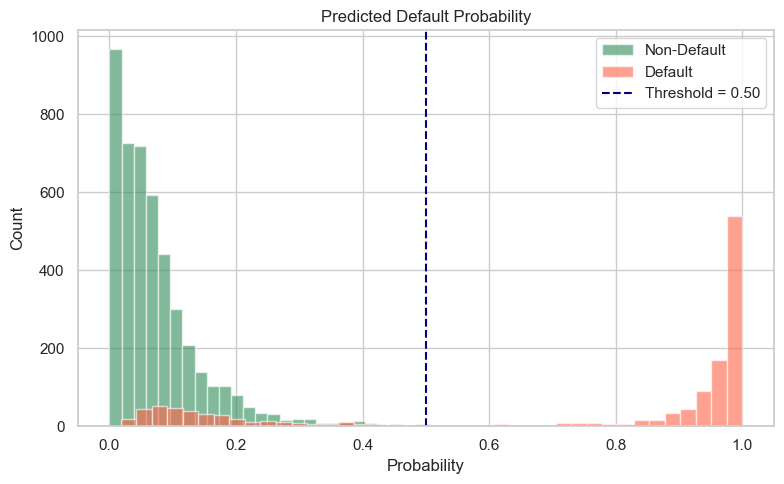

In [43]:
# Plot predicted probabilities to inspect score separation by class.
plt.figure(figsize=(8, 5))
plt.hist(y_cls_prob[y_test_cls == 0], bins=40, alpha=0.6, color="seagreen", label="Non-Default")
plt.hist(y_cls_prob[y_test_cls == 1], bins=40, alpha=0.6, color="tomato", label="Default")
plt.axvline(0.5, color="navy", linestyle="--", label="Threshold = 0.50")
plt.title("Predicted Default Probability")
plt.xlabel("Probability")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

---
## Cross-Validation

Cross-validation gives a more stable performance estimate than one train-test split because the model is evaluated across multiple folds.

In [44]:
# Run cross-validation to estimate model performance across multiple folds.
cv_model_name = "CatBoost" if "CatBoost" in classification_models else "Gradient Boosting"
cv_base_model = classification_models[cv_model_name]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_pipe = Pipeline([
    ("preprocess", make_credit_preprocessor(classification_feature_cols)),
    ("model", clone(cv_base_model)),
])
auc_scores = cross_val_score(cv_pipe, X_cls, y_cls, cv=cv, scoring="roc_auc")
oof_pred = cross_val_predict(cv_pipe, X_cls, y_cls, cv=cv)
cv_report = classification_report(y_cls, oof_pred, digits=3, output_dict=True)
cv_results = pd.DataFrame([{
    "model": cv_model_name,
    "cv_auc_mean": auc_scores.mean(),
    "cv_auc_std": auc_scores.std(),
    "default_recall": cv_report["1"]["recall"],
    "default_precision": cv_report["1"]["precision"],
    "default_f1": cv_report["1"]["f1-score"],
}])
display(cv_results.style.format({
    "cv_auc_mean": "{:.4f}", "cv_auc_std": "{:.4f}",
    "default_recall": "{:.4f}", "default_precision": "{:.4f}", "default_f1": "{:.4f}",
}))

,model,cv_auc_mean,cv_auc_std,default_recall,default_precision,default_f1
0,CatBoost,0.9421,0.0051,0.7261,0.9849,0.8360


---
## Threshold Tuning

The default probability threshold of 0.50 may not be the best lending policy. This step chooses a threshold that minimizes a simple business cost where a missed default is more expensive than a false alarm.

In [45]:
# Evaluate thresholds using a simple lending cost assumption.
COST_FALSE_NEGATIVE = 5
COST_FALSE_POSITIVE = 1
threshold_rows = []
for threshold in np.arange(0.05, 0.96, 0.01):
    y_threshold_pred = (y_cls_prob >= threshold).astype(int)
    false_negative = ((y_threshold_pred == 0) & (y_test_cls == 1)).sum()
    false_positive = ((y_threshold_pred == 1) & (y_test_cls == 0)).sum()
    total_cost = COST_FALSE_NEGATIVE * false_negative + COST_FALSE_POSITIVE * false_positive
    threshold_rows.append({
        "threshold": threshold,
        "false_negative": false_negative,
        "false_positive": false_positive,
        "total_cost": total_cost,
    })
threshold_results = pd.DataFrame(threshold_rows)
best_threshold_row = threshold_results.loc[threshold_results["total_cost"].idxmin()]
best_threshold = float(best_threshold_row["threshold"])
display(best_threshold_row.to_frame("value"))

,value
threshold,0.13
false_negative,181.00
false_positive,702.00
total_cost,1607.00


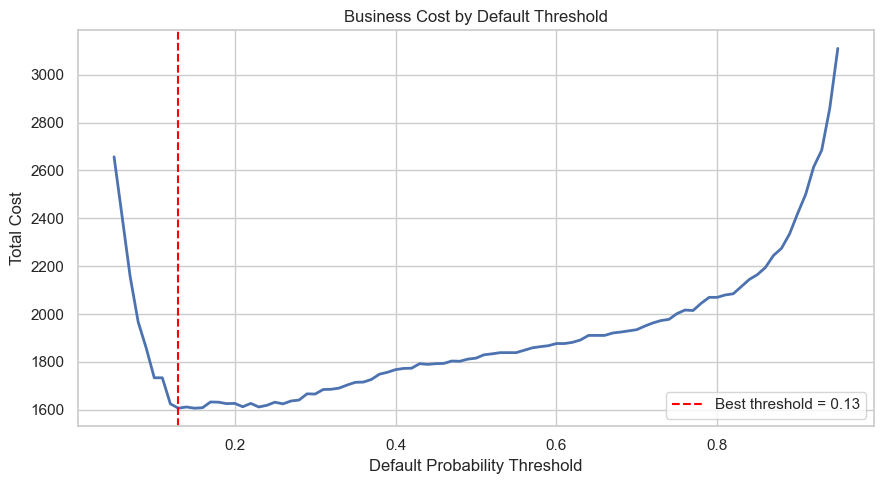

In [46]:
# Plot threshold cost to show the selected operating point.
plt.figure(figsize=(9, 5))
plt.plot(threshold_results["threshold"], threshold_results["total_cost"], linewidth=2)
plt.axvline(best_threshold, color="red", linestyle="--", label=f"Best threshold = {best_threshold:.2f}")
plt.title("Business Cost by Default Threshold")
plt.xlabel("Default Probability Threshold")
plt.ylabel("Total Cost")
plt.legend()
plt.tight_layout()
plt.show()

---
## Optional LightAutoML Classification

LightAutoML is optional and is used as an automated benchmark. If the package is not available, this section is skipped and the manual models remain the main result.

In [47]:
lama_cls_metrics = None
try:
    from lightautoml.automl.presets.tabular_presets import TabularAutoML
    from lightautoml.tasks import Task
    LIGHTAUTOML_AVAILABLE = True
except ImportError:
    LIGHTAUTOML_AVAILABLE = False
    print("LightAutoML is not installed. Optional AutoML classification is skipped.")


def extract_lama_predictions(prediction_object):
    # LightAutoML predictions can be returned as a dataset-like object or an array.
    if hasattr(prediction_object, "data"):
        return np.asarray(prediction_object.data).reshape(-1)
    return np.asarray(prediction_object).reshape(-1)


def get_lightautoml_final_model_name(automl):
    # Try to read the final trained component from LightAutoML's internal levels.
    levels = getattr(automl, "levels", None)
    if not levels:
        return "TabularAutoML"

    # The last level usually contains the final blending/selection component.
    final_level = levels[-1]
    model_names = []
    for pipe in final_level:
        algorithms = getattr(pipe, "ml_algos", None)
        if algorithms:
            # When algorithms are available, report their class names.
            model_names.extend(algo.__class__.__name__ for algo in algorithms)
        else:
            # Otherwise, report the pipeline/component class name.
            model_names.append(pipe.__class__.__name__)

    # Remove duplicate names while preserving order.
    unique_model_names = list(dict.fromkeys(model_names))
    if unique_model_names:
        return " + ".join(unique_model_names)
    return "TabularAutoML"

'nlp' extra dependency package 'fasttext-numpy2' isn't installed. Look at README.md in repo 'LightAutoML' for installation instructions.
'nlp' extra dependency package 'nltk' isn't installed. Look at README.md in repo 'LightAutoML' for installation instructions.
'nlp' extra dependency package 'transformers' isn't installed. Look at README.md in repo 'LightAutoML' for installation instructions.


In [48]:
if LIGHTAUTOML_AVAILABLE:
    lama_cls_data = df_model[classification_feature_cols + [classification_target]].copy()
    # Split data for the optional LightAutoML classification benchmark.
    lama_cls_train, lama_cls_test = train_test_split(
        lama_cls_data, test_size=TEST_SIZE,
        stratify=lama_cls_data[classification_target],
        random_state=RANDOM_STATE,
    )
    lama_cls_task = Task("binary", metric="auc")
    lama_cls_roles = {"target": classification_target}
    lama_cls_model = TabularAutoML(
        task=lama_cls_task,
        timeout=300,
        cpu_limit=4,
        reader_params={"n_jobs": 4, "cv": 5, "random_state": RANDOM_STATE},
    )
    _ = lama_cls_model.fit_predict(lama_cls_train, roles=lama_cls_roles, verbose=1)
    # Predict default probabilities on the holdout set.
    lama_cls_pred = lama_cls_model.predict(lama_cls_test.drop(columns=[classification_target]))
    lama_cls_prob = extract_lama_predictions(lama_cls_pred)
    lama_cls_label = (lama_cls_prob >= 0.50).astype(int)
    y_lama_cls_true = lama_cls_test[classification_target].astype(int)
    # Store LightAutoML source and final model/component name in the result table.
    lama_cls_metrics = pd.DataFrame([{
        "model_source": "LightAutoML",
        "model": get_lightautoml_final_model_name(lama_cls_model),
        "roc_auc": roc_auc_score(y_lama_cls_true, lama_cls_prob),
        "accuracy": accuracy_score(y_lama_cls_true, lama_cls_label),
        "precision": precision_score(y_lama_cls_true, lama_cls_label, zero_division=0),
        "recall": recall_score(y_lama_cls_true, lama_cls_label, zero_division=0),
        "f1": f1_score(y_lama_cls_true, lama_cls_label, zero_division=0),
    }])
    # Display optional LightAutoML classification metrics when available.
    display(lama_cls_metrics.style.format({
        "roc_auc": "{:.4f}", "accuracy": "{:.4f}", "precision": "{:.4f}",
        "recall": "{:.4f}", "f1": "{:.4f}",
    }))
else:
    lama_cls_model = None

[00:54:45] Stdout logging level is INFO.
[00:54:45] Copying TaskTimer may affect the parent PipelineTimer, so copy will create new unlimited TaskTimer
[00:54:45] Task: binary

[00:54:45] Start automl preset with listed constraints:
[00:54:45] - time: 300.00 seconds
[00:54:45] - CPU: 4 cores
[00:54:45] - memory: 16 GB

[00:54:45] Train data shape: (23778, 23)

[00:54:51] Layer 1 train process start. Time left 293.32 secs
[00:54:52] Start fitting Lvl_0_Pipe_0_Mod_0_LinearL2 ...
[00:55:05] Fitting Lvl_0_Pipe_0_Mod_0_LinearL2 finished. score = 0.9090359357588059
[00:55:05] Lvl_0_Pipe_0_Mod_0_LinearL2 fitting and predicting completed
[00:55:05] Time left 279.37 secs

[00:55:08] Selector_LightGBM fitting and predicting completed
[00:55:08] Start fitting Lvl_0_Pipe_1_Mod_0_LightGBM ...
[00:55:19] Fitting Lvl_0_Pipe_1_Mod_0_LightGBM finished. score = 0.919184090517773
[00:55:19] Lvl_0_Pipe_1_Mod_0_LightGBM fitting and predicting completed
[00:55:19] Start hyperparameters optimization for Lvl_0

Optimization Progress:   5%|▍         | 5/101 [00:20<06:32,  4.08s/it, best_trial=3, best_value=0.918]

[00:55:39] Hyperparameters optimization for Lvl_0_Pipe_1_Mod_1_Tuned_LightGBM completed
[00:55:39] Start fitting Lvl_0_Pipe_1_Mod_1_Tuned_LightGBM ...


[00:55:44] Fitting Lvl_0_Pipe_1_Mod_1_Tuned_LightGBM finished. score = 0.9170220473789639
[00:55:44] Lvl_0_Pipe_1_Mod_1_Tuned_LightGBM fitting and predicting completed
[00:55:44] Start fitting Lvl_0_Pipe_1_Mod_2_CatBoost ...
[00:56:05] Fitting Lvl_0_Pipe_1_Mod_2_CatBoost finished. score = 0.918219472637482
[00:56:05] Lvl_0_Pipe_1_Mod_2_CatBoost fitting and predicting completed
[00:56:05] Start hyperparameters optimization for Lvl_0_Pipe_1_Mod_3_Tuned_CatBoost ... Time budget is 80.54 secs


Optimization Progress:  24%|██▍       | 24/101 [01:22<04:26,  3.46s/it, best_trial=6, best_value=0.917]

[00:57:28] Hyperparameters optimization for Lvl_0_Pipe_1_Mod_3_Tuned_CatBoost completed
[00:57:28] Start fitting Lvl_0_Pipe_1_Mod_3_Tuned_CatBoost ...


[00:57:45] Fitting Lvl_0_Pipe_1_Mod_3_Tuned_CatBoost finished. score = 0.9178802388837658
[00:57:45] Lvl_0_Pipe_1_Mod_3_Tuned_CatBoost fitting and predicting completed
[00:57:45] Time left 120.02 secs

[00:57:45] Layer 1 training completed.

[00:57:45] Blending: optimization starts with equal weights. Score = 0.9240144
[00:57:45] Blending: iteration 0: score = 0.9251038, weights = [0.38567808 0.25196758 0.28866792 0.         0.07368644]
[00:57:45] Blending: iteration 1: score = 0.9251150, weights = [0.37179577 0.24426663 0.32540607 0.         0.05853152]
[00:57:46] Blending: iteration 2: score = 0.9251331, weights = [0.37060007 0.2537251  0.31670046 0.05897436 0.        ]
[00:57:46] Blending: iteration 3: score = 0.9251338, weights = [0.37102878 0.25836435 0.31242812 0.05817879 0.        ]
[00:57:47] Blending: iteration 4: score = 0.9251370, weights = [0.36908188 0.23100612 0.31737223 0.08253977 0.        ]
[00:57:47] Blending: best score = 0.9251370, best weights = [0.36908188 0.23100

,model_source,model,roc_auc,accuracy,precision,recall,f1
0,LightAutoML,LinearLBFGS + BoostLGBM + BoostCB,0.9196,0.8878,0.8126,0.6484,0.7213


---
## Regression Dataset for Loan Sizing

Regression models are trained only on non-default loans. This creates a more conservative loan sizing benchmark because the models learn from loans that historically performed successfully.

In [49]:
# Keep only non-default loans for conservative loan-sizing regression.
df_regression = df_model[df_model[classification_target] == 0].copy().reset_index(drop=True)
X_reg = df_regression[regression_feature_cols].copy()
y_loan_amount = df_regression[loan_amount_target].copy()
y_loan_percent = df_regression[loan_percent_target].copy()
regression_setup_summary = pd.DataFrame([{
    "rows": len(df_regression),
    "features": X_reg.shape[1],
    "loan_amount_mean": y_loan_amount.mean(),
    "loan_percent_mean": y_loan_percent.mean(),
}])
display(regression_setup_summary.style.format({
    "loan_amount_mean": "{:.2f}", "loan_percent_mean": "{:.4f}",
}))

,rows,features,loan_amount_mean,loan_percent_mean
0,23070,13,8886.35,0.1527


In [50]:
# Preview regression predictor columns before model training.
display(X_reg.head())

,person_age,person_income,person_emp_length,cb_person_cred_hist_length,log_person_income,employment_to_age_ratio,credit_history_to_age_ratio,default_on_file_binary,person_home_ownership,loan_intent,income_group,age_group,cb_person_default_on_file
0,21,9600,5.0,2,9.169623,0.238095,0.095238,0,OWN,EDUCATION,Low,Young,N
1,23,115000,2.0,4,11.652696,0.086957,0.173913,0,RENT,EDUCATION,High,Young,N
2,23,120000,0.0,4,11.695255,0.000000,0.173913,0,RENT,EDUCATION,High,Young,N
3,25,137000,9.0,2,11.827744,0.360000,0.080000,1,RENT,PERSONAL,High,Young,Y
4,24,10980,0.0,3,9.303922,0.000000,0.125000,0,OWN,PERSONAL,Low,Young,N


In [51]:
# Split regression data into matching train and test datasets.
X_reg_train, X_reg_test, y_amt_train, y_amt_test = train_test_split(
    X_reg, y_loan_amount, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
_, _, y_pct_train, y_pct_test = train_test_split(
    X_reg, y_loan_percent, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

---
## Manual ML Regression Models

Regression models predict numeric targets. MAE, RMSE, and R-squared are used to judge how well each model predicts loan amount and loan percentage.

In [52]:
# Define manual regression models, including linear and tree-based approaches.
regression_models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0, random_state=RANDOM_STATE),
    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=300, min_samples_leaf=10,
        random_state=RANDOM_STATE, n_jobs=-1,
    ),
    "Gradient Boosting Regressor": GradientBoostingRegressor(random_state=RANDOM_STATE),
}
try:
    from catboost import CatBoostRegressor
    regression_models["CatBoost Regressor"] = CatBoostRegressor(
        iterations=300, learning_rate=0.05, depth=6,
        loss_function="RMSE", random_seed=RANDOM_STATE, verbose=0,
    )
except ImportError:
    print("CatBoost is not installed. Continuing with scikit-learn regressors.")

In [53]:
def evaluate_regression_models(models, X_train, X_test, y_train, y_test, target_name):
    # Store metric rows and fitted pipelines for each regression target.
    rows = []
    fitted_models = {}
    for name, model in models.items():
        # Use the same preprocessing for every regressor to keep comparison fair.
        pipe = Pipeline([
            ("preprocess", make_credit_preprocessor(regression_feature_cols)),
            ("model", clone(model)),
        ])
        # Train the model and predict the holdout test records.
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)
        if target_name == loan_percent_target:
            # Loan percent predictions are clipped to a realistic historical range.
            y_pred = np.clip(y_pred, 0, df_regression[loan_percent_target].quantile(0.99))
        # MAE, RMSE, and R-squared describe error size and explanatory strength.
        rows.append({
            "target": target_name,
            "model_source": "Manual",
            "model": name,
            "mae": mean_absolute_error(y_test, y_pred),
            "rmse": np.sqrt(mean_squared_error(y_test, y_pred)),
            "r2": r2_score(y_test, y_pred),
        })
        fitted_models[name] = pipe
    # Lower RMSE is used to select the best regression model.
    metrics = pd.DataFrame(rows).sort_values("rmse").reset_index(drop=True)
    return metrics, fitted_models

In [54]:
# Split regression data into matching train and test datasets.
loan_amount_metrics, loan_amount_models = evaluate_regression_models(
    regression_models, X_reg_train, X_reg_test, y_amt_train, y_amt_test, loan_amount_target
)
display(loan_amount_metrics.style.format({"mae": "{:.2f}", "rmse": "{:.2f}", "r2": "{:.4f}"}))

,target,model_source,model,mae,rmse,r2
0,loan_amnt,Manual,Gradient Boosting Regressor,3868.46,5006.18,0.1841
1,loan_amnt,Manual,Random Forest Regressor,3864.77,5013.44,0.1817
2,loan_amnt,Manual,CatBoost Regressor,3883.99,5022.21,0.1789
3,loan_amnt,Manual,Ridge Regression,3886.01,5026.47,0.1775
4,loan_amnt,Manual,Linear Regression,3886.03,5026.50,0.1774


In [55]:
# Split regression data into matching train and test datasets.
loan_percent_metrics, loan_percent_models = evaluate_regression_models(
    regression_models, X_reg_train, X_reg_test, y_pct_train, y_pct_test, loan_percent_target
)
display(loan_percent_metrics.style.format({"mae": "{:.4f}", "rmse": "{:.4f}", "r2": "{:.4f}"}))

,target,model_source,model,mae,rmse,r2
0,loan_percent_income,Manual,Gradient Boosting Regressor,0.0649,0.0815,0.1144
1,loan_percent_income,Manual,CatBoost Regressor,0.0650,0.0815,0.1138
2,loan_percent_income,Manual,Random Forest Regressor,0.0650,0.0816,0.1107
3,loan_percent_income,Manual,Ridge Regression,0.0658,0.0825,0.0924
4,loan_percent_income,Manual,Linear Regression,0.0658,0.0825,0.0924


---
## Regression Metric Interpretation

**MAE** is the average absolute prediction error. Lower MAE means the model is closer to the actual value on average.

**RMSE** is similar to MAE, but it penalizes large mistakes more strongly. Lower RMSE is better.

**R²** shows how much variation in the target is explained by the model. Higher R² is better, and values closer to 1 indicate stronger predictive performance.

In [56]:
def r2_strength(r2_value):
    # Convert R-squared into a simple project-level interpretation.
    if r2_value >= 0.70:
        return "strong"
    if r2_value >= 0.40:
        return "moderate"
    return "weak"


def regression_conclusion(target_name, best_model, r2_value):
    # Make weak regression performance clear in the conclusion table.
    strength = r2_strength(r2_value)
    if strength == "weak":
        return (
            f"{target_name}: {best_model} has weak prediction performance based on R-squared. "
            "The estimate should be treated as a rough benchmark, not a strong prediction."
        )
    return (
        f"{target_name}: {best_model} has {strength} prediction performance based on R-squared."
    )


best_amount_row = loan_amount_metrics.iloc[0]
best_percent_row = loan_percent_metrics.iloc[0]
amount_mae_ratio = best_amount_row["mae"] / y_amt_test.mean()
amount_rmse_ratio = best_amount_row["rmse"] / y_amt_test.mean()
percent_mae_ratio = best_percent_row["mae"] / y_pct_test.mean()
percent_rmse_ratio = best_percent_row["rmse"] / y_pct_test.mean()

regression_interpretation = pd.DataFrame([
    {
        "target": loan_amount_target,
        "best_model": best_amount_row["model"],
        "mae": best_amount_row["mae"],
        "rmse": best_amount_row["rmse"],
        "r2": best_amount_row["r2"],
        "mae_vs_target_mean": amount_mae_ratio,
        "rmse_vs_target_mean": amount_rmse_ratio,
        "performance_summary": f"{r2_strength(best_amount_row['r2']).title()} explanatory performance by R-squared.",
        "conclusion": regression_conclusion(loan_amount_target, best_amount_row["model"], best_amount_row["r2"]),
    },
    {
        "target": loan_percent_target,
        "best_model": best_percent_row["model"],
        "mae": best_percent_row["mae"],
        "rmse": best_percent_row["rmse"],
        "r2": best_percent_row["r2"],
        "mae_vs_target_mean": percent_mae_ratio,
        "rmse_vs_target_mean": percent_rmse_ratio,
        "performance_summary": f"{r2_strength(best_percent_row['r2']).title()} explanatory performance by R-squared.",
        "conclusion": regression_conclusion(loan_percent_target, best_percent_row["model"], best_percent_row["r2"]),
    },
])

# Display the metric interpretation and final regression conclusion for each target.
display(regression_interpretation.style.format({
    "mae": "{:.4f}", "rmse": "{:.4f}", "r2": "{:.4f}",
    "mae_vs_target_mean": "{:.2%}", "rmse_vs_target_mean": "{:.2%}",
}))

,target,best_model,mae,rmse,r2,mae_vs_target_mean,rmse_vs_target_mean,performance_summary,conclusion
0,loan_amnt,Gradient Boosting Regressor,3868.4586,5006.1777,0.1841,43.84%,56.73%,Weak explanatory performance by R-squared.,"loan_amnt: Gradient Boosting Regressor has weak prediction performance based on R-squared. The estimate should be treated as a rough benchmark, not a strong prediction."
1,loan_percent_income,Gradient Boosting Regressor,0.0649,0.0815,0.1144,42.97%,53.92%,Weak explanatory performance by R-squared.,"loan_percent_income: Gradient Boosting Regressor has weak prediction performance based on R-squared. The estimate should be treated as a rough benchmark, not a strong prediction."


---
## Regression Evaluation Plots

Actual-vs-predicted plots show whether model predictions are close to the observed values. Points closer to the diagonal line indicate better predictions.

In [57]:
# Select the best regression models and generate holdout predictions.
best_amount_name = loan_amount_metrics.iloc[0]["model"]
best_percent_name = loan_percent_metrics.iloc[0]["model"]
best_amount_model = loan_amount_models[best_amount_name]
best_percent_model = loan_percent_models[best_percent_name]
amount_pred = best_amount_model.predict(X_reg_test)
percent_pred = best_percent_model.predict(X_reg_test)
percent_pred = np.clip(percent_pred, 0, df_regression[loan_percent_target].quantile(0.99))

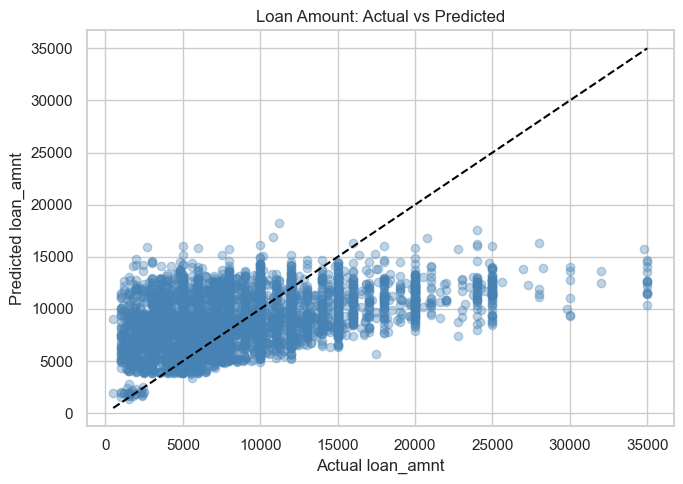

In [58]:
# Plot actual versus predicted loan amount values.
plt.figure(figsize=(7, 5))
plt.scatter(y_amt_test, amount_pred, alpha=0.35, color="steelblue")
plt.plot([y_amt_test.min(), y_amt_test.max()], [y_amt_test.min(), y_amt_test.max()], color="black", linestyle="--")
plt.title("Loan Amount: Actual vs Predicted")
plt.xlabel("Actual loan_amnt")
plt.ylabel("Predicted loan_amnt")
plt.tight_layout()
plt.show()

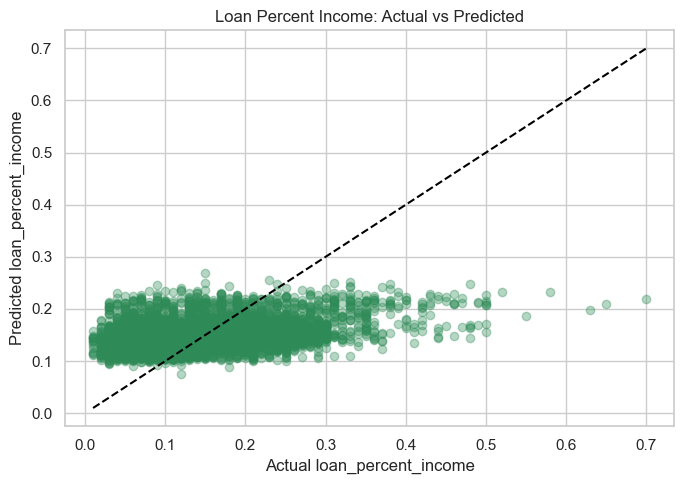

In [59]:
# Plot actual versus predicted loan percent income values.
plt.figure(figsize=(7, 5))
plt.scatter(y_pct_test, percent_pred, alpha=0.35, color="seagreen")
plt.plot([y_pct_test.min(), y_pct_test.max()], [y_pct_test.min(), y_pct_test.max()], color="black", linestyle="--")
plt.title("Loan Percent Income: Actual vs Predicted")
plt.xlabel("Actual loan_percent_income")
plt.ylabel("Predicted loan_percent_income")
plt.tight_layout()
plt.show()

---
## Optional LightAutoML Regression

LightAutoML regression is optional and provides automated benchmark models for `loan_amnt` and `loan_percent_income`. If LightAutoML is unavailable, this section is skipped.

In [60]:
# Prepare optional LightAutoML regression result variables.
lama_amount_metrics = None
lama_percent_metrics = None
try:
    from lightautoml.automl.presets.tabular_presets import TabularAutoML
    from lightautoml.tasks import Task
    LIGHTAUTOML_AVAILABLE = True
except ImportError:
    LIGHTAUTOML_AVAILABLE = False
    print("LightAutoML is not installed. Optional AutoML regression is skipped.")

In [61]:
def run_lightautoml_regression(data, target):
    # Split each regression target separately for an optional automated benchmark.
    train_data, test_data = train_test_split(data, test_size=TEST_SIZE, random_state=RANDOM_STATE)
    task = Task("reg", metric="mse")
    roles = {"target": target}
    # TabularAutoML handles preprocessing, model search, and validation internally.
    automl = TabularAutoML(
        task=task, timeout=300, cpu_limit=4,
        reader_params={"n_jobs": 4, "cv": 5, "random_state": RANDOM_STATE},
    )
    _ = automl.fit_predict(train_data, roles=roles, verbose=1)
    # Predict the test rows and convert LightAutoML output into a flat array.
    prediction = automl.predict(test_data.drop(columns=[target]))
    y_pred = extract_lama_predictions(prediction)
    y_true = test_data[target].values
    if target == loan_percent_target:
        # Keep loan burden predictions in the same realistic range as manual models.
        y_pred = np.clip(y_pred, 0, df_regression[loan_percent_target].quantile(0.99))
    # Store the actual LightAutoML final component name when it can be inspected.
    metrics = pd.DataFrame([{
        "target": target,
        "model_source": "LightAutoML",
        "model": get_lightautoml_final_model_name(automl),
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "r2": r2_score(y_true, y_pred),
    }])
    return automl, metrics, y_true, y_pred

In [62]:
# Run the optional LightAutoML benchmark when the package is available.
if LIGHTAUTOML_AVAILABLE:
    lama_amount_data = df_regression[regression_feature_cols + [loan_amount_target]].copy()
    lama_amount_model, lama_amount_metrics, lama_amount_true, lama_amount_pred = run_lightautoml_regression(
        lama_amount_data, target=loan_amount_target
    )
    display(lama_amount_metrics.style.format({"mae": "{:.2f}", "rmse": "{:.2f}", "r2": "{:.4f}"}))
else:
    lama_amount_model = None

[00:58:15] Stdout logging level is INFO.
[00:58:15] Task: reg

[00:58:15] Start automl preset with listed constraints:
[00:58:15] - time: 300.00 seconds
[00:58:15] - CPU: 4 cores
[00:58:15] - memory: 16 GB

[00:58:15] Train data shape: (18456, 14)

[00:58:16] Layer 1 train process start. Time left 299.64 secs
[00:58:16] Start fitting Lvl_0_Pipe_0_Mod_0_LinearL2 ...
[00:58:25] Fitting Lvl_0_Pipe_0_Mod_0_LinearL2 finished. score = -26160796.0
[00:58:25] Lvl_0_Pipe_0_Mod_0_LinearL2 fitting and predicting completed
[00:58:25] Time left 289.82 secs

[00:58:26] Selector_LightGBM fitting and predicting completed
[00:58:26] Start fitting Lvl_0_Pipe_1_Mod_0_LightGBM ...
[00:58:29] Fitting Lvl_0_Pipe_1_Mod_0_LightGBM finished. score = -26469414.0
[00:58:29] Lvl_0_Pipe_1_Mod_0_LightGBM fitting and predicting completed
[00:58:29] Start hyperparameters optimization for Lvl_0_Pipe_1_Mod_1_Tuned_LightGBM ... Time budget is 51.30 secs


Optimization Progress:  69%|██████▉   | 70/101 [00:51<00:22,  1.36it/s, best_trial=11, best_value=-2.68e+7]

[00:59:21] Hyperparameters optimization for Lvl_0_Pipe_1_Mod_1_Tuned_LightGBM completed
[00:59:21] Start fitting Lvl_0_Pipe_1_Mod_1_Tuned_LightGBM ...


[00:59:21] Fitting Lvl_0_Pipe_1_Mod_1_Tuned_LightGBM finished. score = -26400818.0
[00:59:21] Lvl_0_Pipe_1_Mod_1_Tuned_LightGBM fitting and predicting completed
[00:59:21] Start fitting Lvl_0_Pipe_1_Mod_2_CatBoost ...
[00:59:26] Fitting Lvl_0_Pipe_1_Mod_2_CatBoost finished. score = -26380238.0
[00:59:26] Lvl_0_Pipe_1_Mod_2_CatBoost fitting and predicting completed
[00:59:26] Start hyperparameters optimization for Lvl_0_Pipe_1_Mod_3_Tuned_CatBoost ... Time budget is 154.21 secs


Optimization Progress: 100%|██████████| 101/101 [01:22<00:00,  1.22it/s, best_trial=56, best_value=-2.67e+7]

[01:00:49] Hyperparameters optimization for Lvl_0_Pipe_1_Mod_3_Tuned_CatBoost completed
[01:00:49] Start fitting Lvl_0_Pipe_1_Mod_3_Tuned_CatBoost ...


[01:00:53] Fitting Lvl_0_Pipe_1_Mod_3_Tuned_CatBoost finished. score = -26387314.0
[01:00:53] Lvl_0_Pipe_1_Mod_3_Tuned_CatBoost fitting and predicting completed
[01:00:53] Time left 141.80 secs

[01:00:54] Layer 1 training completed.

[01:00:54] Blending: optimization starts with equal weights. Score = -26250222.0000000
[01:00:54] Blending: iteration 0: score = -26126560.0000000, weights = [0.7940347  0.12624253 0.0797227  0.         0.        ]
[01:00:54] Blending: iteration 1: score = -26125162.0000000, weights = [0.7374376  0.14986151 0.11270088 0.         0.        ]
[01:00:54] Blending: iteration 2: score = -26125088.0000000, weights = [0.7375626  0.14044659 0.12199079 0.         0.        ]
[01:00:54] Blending: iteration 3: score = -26125034.0000000, weights = [0.73764706 0.13241899 0.12993394 0.         0.        ]
[01:00:54] Blending: iteration 4: score = -26124994.0000000, weights = [0.73773503 0.12554842 0.13671656 0.         0.        ]
[01:00:54] Blending: best score = -261

,target,model_source,model,mae,rmse,r2
0,loan_amnt,LightAutoML,LinearLBFGS + BoostLGBM,3874.01,5013.03,0.1819


In [63]:
# Run the optional LightAutoML benchmark when the package is available.
if LIGHTAUTOML_AVAILABLE:
    lama_percent_data = df_regression[regression_feature_cols + [loan_percent_target]].copy()
    lama_percent_model, lama_percent_metrics, lama_percent_true, lama_percent_pred = run_lightautoml_regression(
        lama_percent_data, target=loan_percent_target
    )
    display(lama_percent_metrics.style.format({"mae": "{:.4f}", "rmse": "{:.4f}", "r2": "{:.4f}"}))
else:
    lama_percent_model = None

[01:00:54] Stdout logging level is INFO.
[01:00:54] Task: reg

[01:00:54] Start automl preset with listed constraints:
[01:00:54] - time: 300.00 seconds
[01:00:54] - CPU: 4 cores
[01:00:54] - memory: 16 GB

[01:00:54] Train data shape: (18456, 14)

[01:00:54] Layer 1 train process start. Time left 299.64 secs
[01:00:55] Start fitting Lvl_0_Pipe_0_Mod_0_LinearL2 ...
[01:00:56] Fitting Lvl_0_Pipe_0_Mod_0_LinearL2 finished. score = -0.007105879426709584
[01:00:56] Lvl_0_Pipe_0_Mod_0_LinearL2 fitting and predicting completed
[01:00:56] Time left 298.29 secs

[01:00:56] Selector_LightGBM fitting and predicting completed
[01:00:56] Start fitting Lvl_0_Pipe_1_Mod_0_LightGBM ...
[01:00:59] Fitting Lvl_0_Pipe_1_Mod_0_LightGBM finished. score = -0.007120287401895375
[01:00:59] Lvl_0_Pipe_1_Mod_0_LightGBM fitting and predicting completed
[01:00:59] Start hyperparameters optimization for Lvl_0_Pipe_1_Mod_1_Tuned_LightGBM ... Time budget is 56.94 secs


Optimization Progress:  87%|████████▋ | 88/101 [00:57<00:08,  1.52it/s, best_trial=57, best_value=-0.00704]

[01:01:56] Hyperparameters optimization for Lvl_0_Pipe_1_Mod_1_Tuned_LightGBM completed
[01:01:56] Start fitting Lvl_0_Pipe_1_Mod_1_Tuned_LightGBM ...


[01:01:58] Fitting Lvl_0_Pipe_1_Mod_1_Tuned_LightGBM finished. score = -0.0071074876113926145
[01:01:58] Lvl_0_Pipe_1_Mod_1_Tuned_LightGBM fitting and predicting completed
[01:01:58] Start fitting Lvl_0_Pipe_1_Mod_2_CatBoost ...
[01:02:03] Fitting Lvl_0_Pipe_1_Mod_2_CatBoost finished. score = -0.0071339910506216225
[01:02:03] Lvl_0_Pipe_1_Mod_2_CatBoost fitting and predicting completed
[01:02:03] Start hyperparameters optimization for Lvl_0_Pipe_1_Mod_3_Tuned_CatBoost ... Time budget is 154.93 secs


Optimization Progress: 100%|██████████| 101/101 [01:25<00:00,  1.18it/s, best_trial=74, best_value=-0.00709]

[01:03:28] Hyperparameters optimization for Lvl_0_Pipe_1_Mod_3_Tuned_CatBoost completed
[01:03:28] Start fitting Lvl_0_Pipe_1_Mod_3_Tuned_CatBoost ...


[01:03:31] Fitting Lvl_0_Pipe_1_Mod_3_Tuned_CatBoost finished. score = -0.007130706936354252
[01:03:31] Lvl_0_Pipe_1_Mod_3_Tuned_CatBoost fitting and predicting completed
[01:03:31] Time left 142.69 secs

[01:03:31] Layer 1 training completed.

[01:03:31] Blending: optimization starts with equal weights. Score = -0.0070894
[01:03:31] Blending: iteration 0: score = -0.0070698, weights = [0.41677162 0.23060173 0.3526267  0.         0.        ]
[01:03:31] Blending: iteration 1: score = -0.0070665, weights = [0.4926276  0.07661311 0.4307593  0.         0.        ]
[01:03:32] Blending: iteration 2: score = -0.0070655, weights = [0.50487727 0.         0.49512273 0.         0.        ]
[01:03:32] Blending: no improvements for score. Terminated.

[01:03:32] Blending: best score = -0.0070655, best weights = [0.50487727 0.         0.49512273 0.         0.        ]
[01:03:32] Automl preset training completed in 157.52 seconds

[01:03:32] Model description:
Final prediction for new objects (level 

,target,model_source,model,mae,rmse,r2
0,loan_percent_income,LightAutoML,LinearLBFGS + BoostLGBM,0.0653,0.0825,0.0907


---
## Manual vs AutoML Comparison

The tables below compare the best manual models against LightAutoML when AutoML results are available. Manual models remain the primary workflow; AutoML is an optional benchmark.

### Classification Model Comparison

In [64]:
classification_compare_parts = [manual_cls_best[["model_source", "model", "roc_auc", "accuracy", "precision", "recall", "f1"]]]
if bn_metrics is not None:
    classification_compare_parts.append(bn_metrics[["model_source", "model", "roc_auc", "accuracy", "precision", "recall", "f1"]])
if lama_cls_metrics is not None:
    classification_compare_parts.append(lama_cls_metrics[["model_source", "model", "roc_auc", "accuracy", "precision", "recall", "f1"]])
classification_comparison = pd.concat(classification_compare_parts, ignore_index=True)

# Display manual and LightAutoML classification results together.
display(classification_comparison.style.format({
    "roc_auc": "{:.4f}", "accuracy": "{:.4f}", "precision": "{:.4f}",
    "recall": "{:.4f}", "f1": "{:.4f}",
}))

,model_source,model,roc_auc,accuracy,precision,recall,f1
0,Manual,CatBoost,0.9411,0.9374,0.9888,0.7288,0.8391
1,Bayesian Network,pgmpy HillClimbSearch + VariableElimination,0.8474,0.8353,0.7152,0.4395,0.5444
2,LightAutoML,LinearLBFGS + BoostLGBM + BoostCB,0.9196,0.8878,0.8126,0.6484,0.7213


### Regression Model Comparison: Loan Amount

In [65]:
amount_compare_parts = [loan_amount_metrics.iloc[[0]][["target", "model_source", "model", "mae", "rmse", "r2"]]]
if lama_amount_metrics is not None:
    amount_compare_parts.append(lama_amount_metrics[["target", "model_source", "model", "mae", "rmse", "r2"]])
amount_model_comparison = pd.concat(amount_compare_parts, ignore_index=True)

# Display the best manual model beside optional LightAutoML for loan amount.
display(amount_model_comparison.style.format({"mae": "{:.2f}", "rmse": "{:.2f}", "r2": "{:.4f}"}))

,target,model_source,model,mae,rmse,r2
0,loan_amnt,Manual,Gradient Boosting Regressor,3868.46,5006.18,0.1841
1,loan_amnt,LightAutoML,LinearLBFGS + BoostLGBM,3874.01,5013.03,0.1819


### Regression Model Comparison: Loan Percent Income

In [66]:
percent_compare_parts = [loan_percent_metrics.iloc[[0]][["target", "model_source", "model", "mae", "rmse", "r2"]]]
if lama_percent_metrics is not None:
    percent_compare_parts.append(lama_percent_metrics[["target", "model_source", "model", "mae", "rmse", "r2"]])
percent_model_comparison = pd.concat(percent_compare_parts, ignore_index=True)

# Display the best manual model beside optional LightAutoML for loan percent income.
display(percent_model_comparison.style.format({"mae": "{:.4f}", "rmse": "{:.4f}", "r2": "{:.4f}"}))

,target,model_source,model,mae,rmse,r2
0,loan_percent_income,Manual,Gradient Boosting Regressor,0.0649,0.0815,0.1144
1,loan_percent_income,LightAutoML,LinearLBFGS + BoostLGBM,0.0653,0.0825,0.0907


---
## Example Applicant Loan Estimate

The example shows how the regression models can estimate a loan amount and loan percentage for one applicant. The conservative recommendation is the lower of the direct loan amount estimate and the income-based estimate.

In [67]:
def prepare_applicant_for_regression(applicant_dict):
    # Convert one applicant dictionary into a dataframe.
    applicant_df = pd.DataFrame([applicant_dict])
    # Apply the same feature engineering used during model training.
    applicant_df = add_credit_features(applicant_df)
    # Keep only the regression predictor columns expected by the trained pipelines.
    return applicant_df[regression_feature_cols]


def estimate_loan_for_applicant(applicant_dict, amount_model, percent_model):
    # Prepare the applicant record in the same format as the regression training data.
    applicant_features = prepare_applicant_for_regression(applicant_dict)
    # Predict loan amount directly from the loan amount regression model.
    predicted_amount = float(amount_model.predict(applicant_features)[0])
    # Predict loan percent of income from the loan burden regression model.
    predicted_percent = float(percent_model.predict(applicant_features)[0])
    max_reasonable_percent = float(df_regression[loan_percent_target].quantile(0.99))
    # Clip extreme percentage predictions to the historical non-default range.
    predicted_percent = float(np.clip(predicted_percent, 0, max_reasonable_percent))
    # Convert the predicted percentage into an income-based dollar amount.
    income_based_amount = float(applicant_dict["person_income"]) * predicted_percent
    # Use the smaller amount as the conservative recommendation.
    conservative_amount = min(predicted_amount, income_based_amount)
    return {
        "predicted_loan_amount": round(predicted_amount, 2),
        "predicted_loan_percent_income": round(predicted_percent, 4),
        "income_based_amount": round(income_based_amount, 2),
        "conservative_recommended_amount": round(conservative_amount, 2),
    }

In [68]:
example_applicant = {
    "person_age": 28,
    "person_income": 65000,
    "person_home_ownership": "RENT",
    "person_emp_length": 5,
    "loan_intent": "DEBTCONSOLIDATION",
    "loan_grade": "B",
    "loan_amnt": 12000,
    "loan_int_rate": 11.0,
    "loan_percent_income": 12000 / 65000,
    "loan_status": 0,
    "cb_person_default_on_file": "N",
    "cb_person_cred_hist_length": 6,
}
loan_estimate = estimate_loan_for_applicant(example_applicant, best_amount_model, best_percent_model)
loan_estimate_table = pd.DataFrame([loan_estimate])

# Display the final applicant estimate table.
display(loan_estimate_table)

# Print the rule used to calculate the conservative recommendation.
print("Interpretation: the conservative recommendation is the lower of the direct loan amount estimate and the income-based estimate.")

,predicted_loan_amount,predicted_loan_percent_income,income_based_amount,conservative_recommended_amount
0,9047.73,0.1403,9122.04,9047.73


Interpretation: the conservative recommendation is the lower of the direct loan amount estimate and the income-based estimate.
